In [7]:
##Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [8]:
##Generate Dataset
import pandas as pd
import numpy as np

np.random.seed(42)

n = 5000

customer_id = np.arange(10001, 10001+n)

gender = np.random.choice(
    ['Male','Female'],
    n
)

age = np.random.randint(18,70,n)

city = np.random.choice(
    ['Mumbai','Delhi','Bangalore','Pune','Hyderabad','Chennai'],
    n
)

contract = np.random.choice(
    ['Month-to-Month','One Year','Two Year'],
    n,
    p=[0.55,0.25,0.20]
)

internet = np.random.choice(
    ['Fiber','DSL','No Internet'],
    n,
    p=[0.50,0.35,0.15]
)

monthly_charges = np.random.randint(300,2500,n)

tenure = np.random.randint(1,72,n)

support_calls = np.random.randint(0,10,n)

payment = np.random.choice(
    ['Credit Card','Debit Card','UPI','Net Banking'],
    n
)

churn = []

for i in range(n):
    if tenure[i] < 12 and support_calls[i] > 5:
        churn.append("Yes")
    elif contract[i] == "Month-to-Month" and monthly_charges[i] > 1500:
        churn.append("Yes")
    else:
        churn.append(np.random.choice(["Yes","No"],p=[0.20,0.80]))

df = pd.DataFrame({

    "CustomerID":customer_id,
    "Gender":gender,
    "Age":age,
    "City":city,
    "Contract":contract,
    "InternetService":internet,
    "MonthlyCharges":monthly_charges,
    "Tenure":tenure,
    "SupportCalls":support_calls,
    "PaymentMethod":payment,
    "Churn":churn

})

df.to_csv("telecom_customer_churn.csv",index=False)

print(df.head())

   CustomerID  Gender  Age       City        Contract InternetService  \
0       10001    Male   68      Delhi        Two Year     No Internet   
1       10002  Female   64    Chennai        Two Year           Fiber   
2       10003    Male   64  Bangalore        One Year           Fiber   
3       10004    Male   21    Chennai  Month-to-Month     No Internet   
4       10005    Male   24      Delhi  Month-to-Month             DSL   

   MonthlyCharges  Tenure  SupportCalls PaymentMethod Churn  
0             591      53             9   Credit Card    No  
1            1942      51             4   Credit Card    No  
2            1705      13             2   Credit Card    No  
3             877      41             0    Debit Card    No  
4            1461      11             5   Credit Card    No  


In [9]:
##Load Data
df = pd.read_csv("telecom_customer_churn.csv")

df.head()

,CustomerID,Gender,Age,City,Contract,InternetService,MonthlyCharges,Tenure,SupportCalls,PaymentMethod,Churn
0,10001,Male,68,Delhi,Two Year,No Internet,591,53,9,Credit Card,No
1,10002,Female,64,Chennai,Two Year,Fiber,1942,51,4,Credit Card,No
2,10003,Male,64,Bangalore,One Year,Fiber,1705,13,2,Credit Card,No
3,10004,Male,21,Chennai,Month-to-Month,No Internet,877,41,0,Debit Card,No
4,10005,Male,24,Delhi,Month-to-Month,DSL,1461,11,5,Credit Card,No


In [10]:
##Basic Information
df.info()

df.describe()

df.shape

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       5000 non-null   int64 
 1   Gender           5000 non-null   object
 2   Age              5000 non-null   int64 
 3   City             5000 non-null   object
 4   Contract         5000 non-null   object
 5   InternetService  5000 non-null   object
 6   MonthlyCharges   5000 non-null   int64 
 7   Tenure           5000 non-null   int64 
 8   SupportCalls     5000 non-null   int64 
 9   PaymentMethod    5000 non-null   object
 10  Churn            5000 non-null   object
dtypes: int64(5), object(6)
memory usage: 429.8+ KB


Index(['CustomerID', 'Gender', 'Age', 'City', 'Contract', 'InternetService',
       'MonthlyCharges', 'Tenure', 'SupportCalls', 'PaymentMethod', 'Churn'],
      dtype='object')

In [11]:
##Check Missing Values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
City,0
Contract,0
InternetService,0
MonthlyCharges,0
Tenure,0
SupportCalls,0
PaymentMethod,0


In [12]:
##Check Duplicate Values
df.duplicated().sum()

np.int64(0)

In [15]:
##Data Cleaning
df['Gender']=df['Gender'].astype('category')
df['City']=df['City'].astype('category')
df['Contract']=df['Contract'].astype('category')
df['PaymentMethod']=df['PaymentMethod'].astype('category')
df['InternetService']=df['InternetService'].astype('category')
df['Churn']=df['Churn'].astype('category')

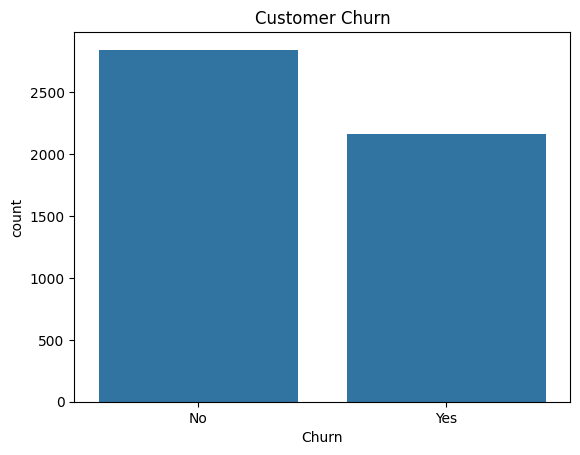

In [16]:
## EDA
#Overall Churn Rate
sns.countplot(x='Churn',data=df)

plt.title("Customer Churn")
plt.show()

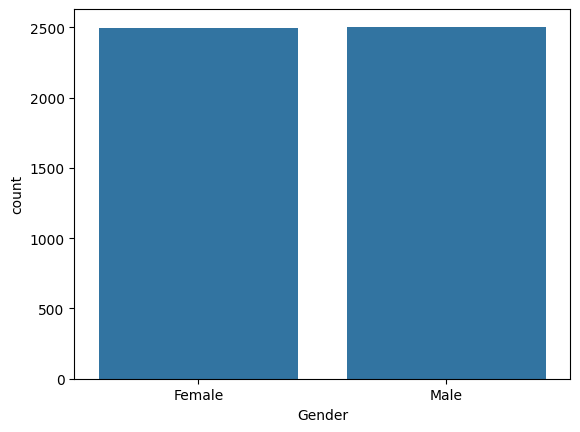

In [17]:
##Gender Distribution
sns.countplot(x='Gender',data=df)
plt.show()

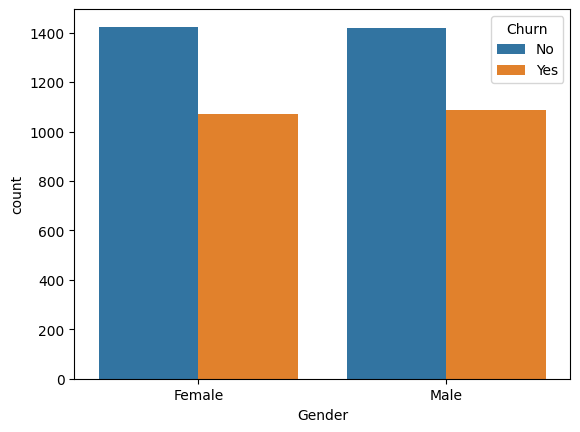

In [18]:
#Churn by Gender
sns.countplot(
    x='Gender',
    hue='Churn',
    data=df
)

plt.show()

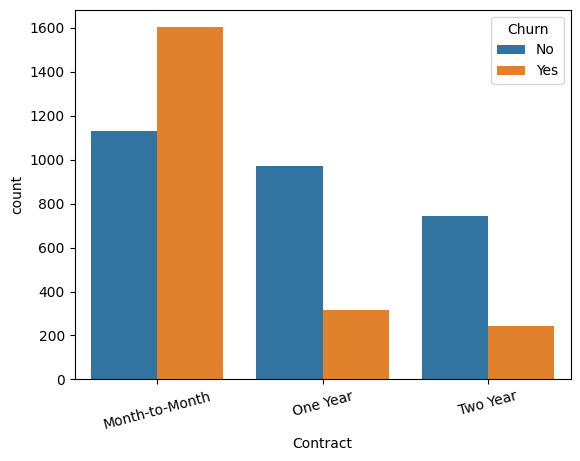

In [19]:
# Contract Type
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.xticks(rotation=15)

plt.show()

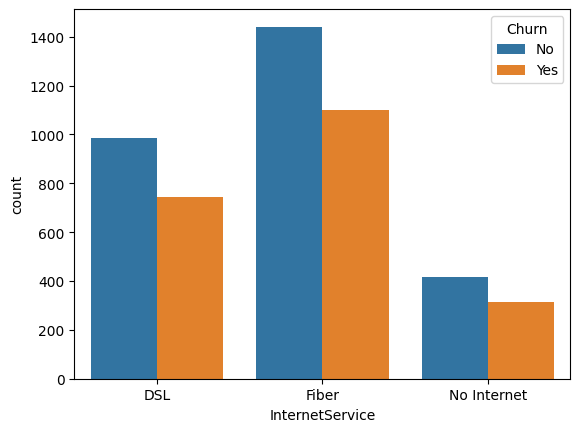

In [20]:
# Internet Service
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.show()

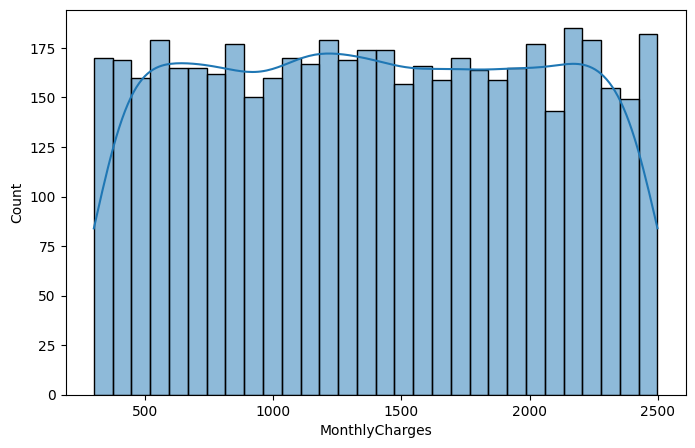

In [21]:
## Monthly Charges by Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['MonthlyCharges'],
    bins=30,
    kde=True
)

plt.show()

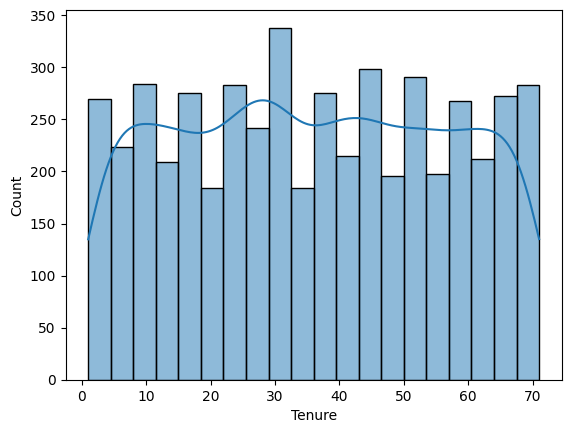

In [22]:
# Tenure Distribution
sns.histplot(
    df['Tenure'],
    bins=20,
    kde=True
)

plt.show()

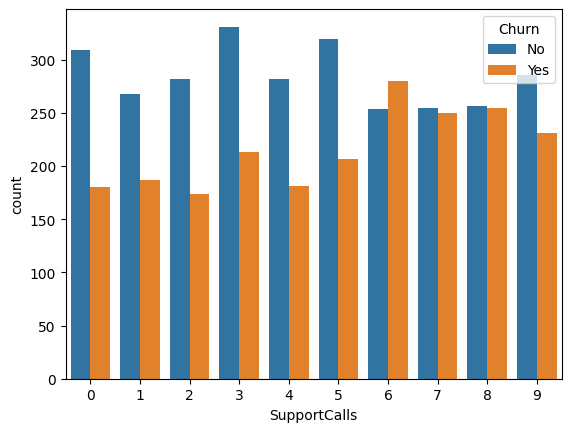

In [23]:
# Support Calls
sns.countplot(
    x='SupportCalls',
    hue='Churn',
    data=df
)

plt.show()

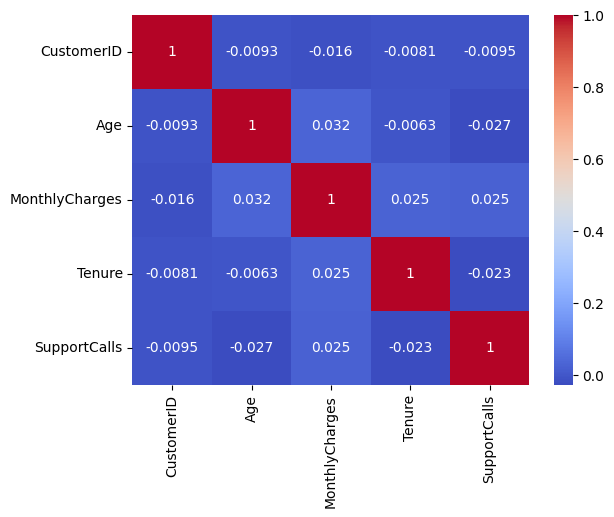

In [24]:
# Correlation Heatmap
numeric = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

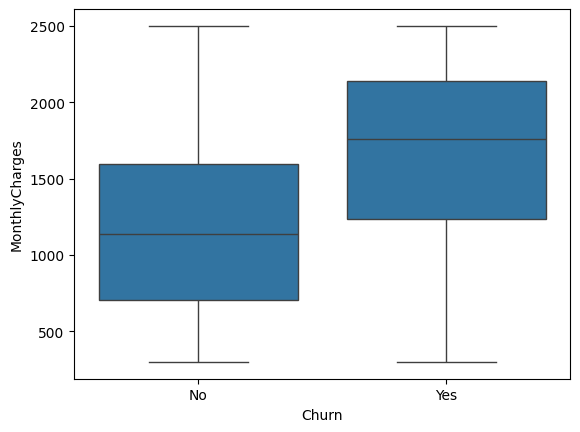

In [26]:
# Box plot
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.show()